In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import warnings
warnings.filterwarnings("ignore")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


# Reading Initial Data

In [2]:
df = pd.read_csv("/kaggle/input/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.shape

(284807, 31)

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,3.918649e-15,5.682686e-16,-8.761736e-15,2.811118e-15,-1.552103e-15,2.040130e-15,-1.698953e-15,-1.893285e-16,-3.147640e-15,...,1.473120e-16,8.042109e-16,5.282512e-16,4.456271e-15,1.426896e-15,1.701640e-15,-3.662252e-16,-1.217809e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().any()

Time      False
V1        False
V2        False
V3        False
V4        False
V5        False
V6        False
V7        False
V8        False
V9        False
V10       False
V11       False
V12       False
V13       False
V14       False
V15       False
V16       False
V17       False
V18       False
V19       False
V20       False
V21       False
V22       False
V23       False
V24       False
V25       False
V26       False
V27       False
V28       False
Amount    False
Class     False
dtype: bool

# Exploratory Data Analysis

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns
#sns.set_style("white")

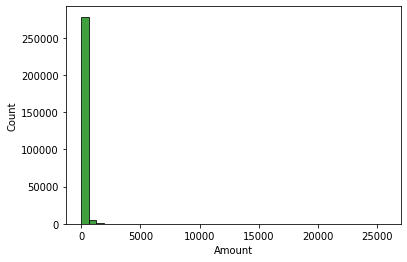

In [8]:
sns.histplot(df['Amount'],bins =40,color="green")
sns.set_style("darkgrid")

### We see that the amount column does not follow any distribution, so we need to convert it to a log distribution


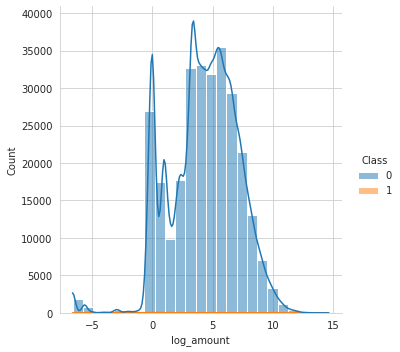

In [9]:
sns.set_style("whitegrid")
df["log_amount"] = np.log2(df["Amount"]+0.01)
sns.displot(x = "log_amount",bins = 25, kde = True, hue = "Class", data=df)


<AxesSubplot:xlabel='Class', ylabel='log_amount'>

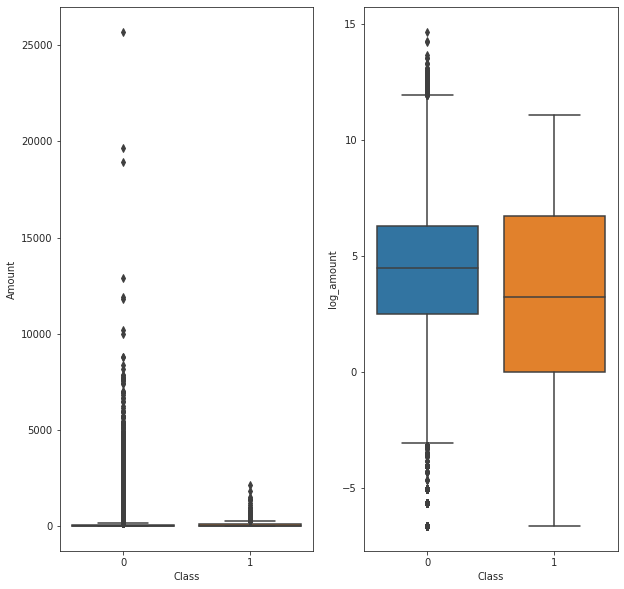

In [10]:
sns.set_style("ticks")
fig,ax  = plt.subplots(ncols = 2,nrows =1,figsize = (10,10))
ax.flatten()
sns.boxplot(x = "Class", y = "Amount", data=df, ax = ax[0])
sns.boxplot(x = "Class",y = "log_amount", data =df, ax = ax[1])

### Fradulent Transaction have no outliers 

<AxesSubplot:xlabel='Class', ylabel='count'>

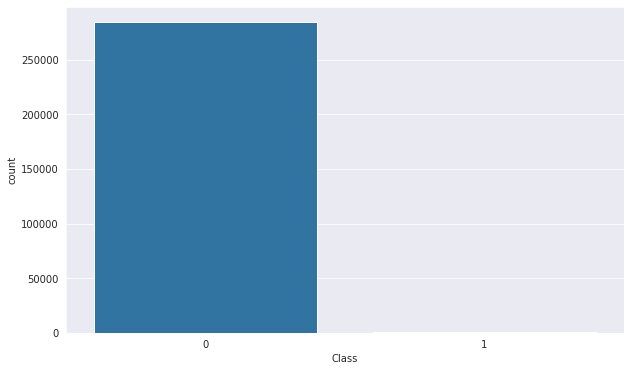

In [11]:
sns.set_style("darkgrid")
plt.figure(figsize = (10,6))
sns.countplot(x = "Class", data=df)

In [12]:
fraud = df[df["Class"]==1]
not_fraud = df[df["Class"]==0]

In [13]:
print(fraud.shape,not_fraud.shape)

(492, 32) (284315, 32)


In [14]:
x = df.drop(["Class"], axis = 1)
y = df["Class"]

In [15]:
x.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,log_amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,7.225256
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1.432959
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,8.564797
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,6.948484
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,6.129283


### We see that the data is highly imbalanced and we need to make them balanced to reduce bias towards one particular class

# Handling Imbalanced Data

In [16]:
from imblearn.under_sampling import NearMiss

nm = NearMiss()

x_nm, y_nm = nm.fit_resample(x, y)

In [17]:
print(x_nm.shape,y_nm.shape)

(984, 31) (984,)


# Standarization

In [18]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [19]:
x_scaled = scalar.fit_transform(x_nm)

# Model Creation and comparision with other models

In [20]:
from sklearn.model_selection import train_test_split, cross_val_score
x_train,x_test,y_train,y_test = train_test_split(x_scaled,y_nm, test_size = 0.25)

In [21]:
scores = {}
acc = []
cv_scores = []
def model(model):
    model.fit(x_train,y_train)
    score = model.score(x_test,y_test)
    print("Accuracy: {}".format(score))
    cv_score = cross_val_score(model,x_train,y_train,cv=5)
    print("Cross Val Score: {}".format(np.mean(cv_score)))
    acc.append(score)
    cv_scores.append(np.mean(cv_score))
    
    

In [22]:
from xgboost import XGBClassifier
clf = XGBClassifier()
model(clf)


[20:54:33] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
Accuracy: 0.9390243902439024
[20:54:33] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[20:54:33] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you'd like to restore the old behavior.
[20:54:33] WARNING: ../src/learner.cc:1061: Starting in XGBoost 1.3.0, the default evaluation metric used with the objective 'binary:logistic' was changed from 'error' to 'logloss'. Explicitly set eval_metric if you

In [23]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
model(clf)

Accuracy: 0.9390243902439024
Cross Val Score: 0.9525556168413312


In [24]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()
model(clf)

Accuracy: 0.9349593495934959
Cross Val Score: 0.9607004964147821


In [25]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
model(clf)

Accuracy: 0.9471544715447154
Cross Val Score: 0.9553042838757124


In [26]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier()
model(clf)

Accuracy: 0.8983739837398373
Cross Val Score: 0.929490715205001


In [27]:
from sklearn.svm import SVC
clf = SVC()
model(clf)

Accuracy: 0.943089430894309
Cross Val Score: 0.9471134399705828


In [28]:
from sklearn.naive_bayes import GaussianNB
clf = GaussianNB()
model(clf)

Accuracy: 0.9065040650406504
Cross Val Score: 0.9308420665563523


In [29]:
from sklearn.ensemble import AdaBoostClassifier
clf = AdaBoostClassifier()
model(clf)

Accuracy: 0.9471544715447154
Cross Val Score: 0.9620794263651404


In [30]:
from sklearn.ensemble import GradientBoostingClassifier
clf = GradientBoostingClassifier()
model(clf)

Accuracy: 0.9390243902439024
Cross Val Score: 0.9593675307961022


In [31]:
models = ["XGBClassifier","LogisticRegression","RandomForestClassifier","DecisionTreeClassifier","KNeighborsClassifier","SVC","GaussianNB","AdaBoostClassifier","GradientBoostingClassifier"]
acc

[0.9390243902439024,
 0.9390243902439024,
 0.9349593495934959,
 0.9471544715447154,
 0.8983739837398373,
 0.943089430894309,
 0.9065040650406504,
 0.9471544715447154,
 0.9390243902439024]

In [32]:
cv_scores

[0.9566372494943923,
 0.9525556168413312,
 0.9607004964147821,
 0.9553042838757124,
 0.929490715205001,
 0.9471134399705828,
 0.9308420665563523,
 0.9620794263651404,
 0.9593675307961022]

In [33]:
scores = { "Model Name" : models , "Accuracy Score" : acc, "Cross val Score": cv_scores}

In [34]:
df1 = pd.DataFrame(scores)

In [35]:
df1

,Model Name,Accuracy Score,Cross val Score
0,XGBClassifier,0.939024,0.956637
1,LogisticRegression,0.939024,0.952556
2,RandomForestClassifier,0.934959,0.960700
3,DecisionTreeClassifier,0.947154,0.955304
4,KNeighborsClassifier,0.898374,0.929491
5,SVC,0.943089,0.947113
6,GaussianNB,0.906504,0.930842
7,AdaBoostClassifier,0.947154,0.962079
8,GradientBoostingClassifier,0.939024,0.959368


Text(0.5, 1.0, 'Model Comparision wrt Score')

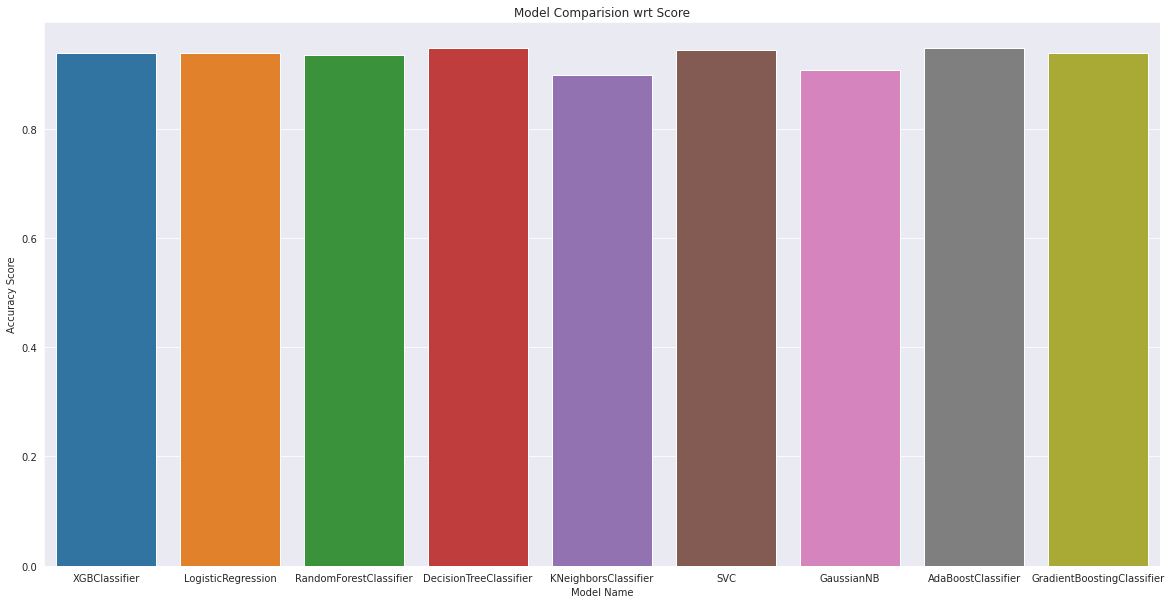

In [36]:
plt.figure(figsize = (20,10))
sns.barplot(x = "Model Name", y = "Accuracy Score", data=df1)
plt.title("Model Comparision wrt Score")

Text(0.5, 1.0, 'Model Comparision wrt Cross validation')

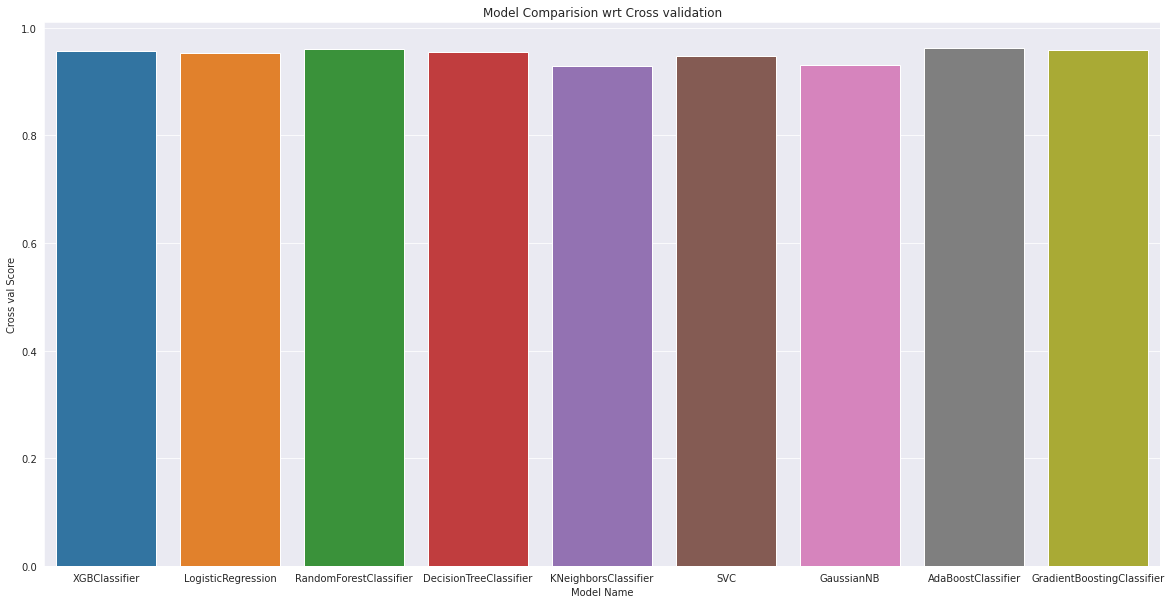

In [37]:
plt.figure(figsize = (20,10))
sns.barplot(x = "Model Name", y = "Cross val Score", data=df1)
plt.title("Model Comparision wrt Cross validation")

# We see that ADA BOOST Classifier performs the best with an accuracy of 97.5%